## Agent 간 메시지 전달 구조

01, 02번 노트북에서는 모든 sub-agent가 **하나의 공유 State(공용 칠판)**를 함께 읽고 쓰는 방식으로 협업했다. 이 방식은 구현이 간단하지만, agent 수가 늘어날수록 "누가 이 필드를 언제 바꿨는지" 추적하기 어렵고, 모든 agent가 State 스키마 전체를 알아야 한다는 단점이 있다.

**메시지 전달(message passing)** 구조는 이와 다르게 접근한다.

- 각 agent는 자신의 **inbox(수신함)**만 확인하고, 처리 결과를 **다른 agent에게 보내는 메시지**로 표현한다.
- 메시지는 `sender`(보낸 agent), `receiver`(받을 agent), `type`(request/response/notify), `content`(내용)로 구성된 명시적인 객체다.
- agent는 상대방의 내부 상태를 알 필요 없이, **메시지 형식(프로토콜)**만 알면 된다 — 실제 서비스로 분리 배포된 agent들이 메시지 큐(Kafka, SQS 등)로 통신하는 구조와 동일한 아이디어다.
- 모든 메시지가 로그로 남기 때문에 "누가 누구에게 무엇을 언제 보냈는지" 완전한 감사 추적(audit trail)이 가능하다.

```
order_intake --request(재고 확인)--> inventory
order_intake <--response(재고 결과)-- inventory
order_intake --request(배송 준비)--> shipping        (재고가 있을 때)
order_intake <--response(운송장)---- shipping
order_intake --notify(처리 결과)---> customer_service
```

이 노트북에서는 온라인 쇼핑몰의 주문 처리를 예시로, `order_intake`(주문 접수) → `inventory`(재고 확인) → `shipping`(배송) → `customer_service`(고객 응대) 4개 agent가 **메시지만 주고받으며** 협업하는 구조를 LangGraph로 구현한다. 그래프의 라우팅 로직은 단 하나 — **"메시지의 receiver가 다음 실행 노드를 결정한다"**는 규칙뿐이며, 어떤 agent가 어떤 판단을 내리는지는 라우터가 전혀 몰라도 된다.

In [1]:
import os
from dotenv import load_dotenv

# .env 파일에서 API 키 불러오기
load_dotenv("C:/env/.env")

True

### [0] 사전 준비: LLM, 메시지 스키마, 상태(State)

In [2]:
from typing import Dict, List, Literal, TypedDict

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [3]:
from pydantic import BaseModel, Field


class Message(BaseModel):
    sender: str = Field(description="메시지를 보낸 agent")
    receiver: str = Field(description="메시지를 받을 agent")
    type: Literal["request", "response", "notify"] = Field(description="request=요청, response=응답, notify=결과 통보")
    content: str = Field(description="메시지 내용")


class State(TypedDict):
    order: dict                       # 이 예제에서 필요한 최소한의 공유 컨텍스트 (주문 상품/수량)
    log: List[dict]                   # 지금까지 오간 모든 메시지 기록 (감사 추적용)
    inbox: Dict[str, List[dict]]      # agent별 수신 대기 메시지함
    next_agent: str                   # 마지막 메시지의 수신자 = 다음에 실행할 노드
    final: str                        # 고객에게 전달된 최종 안내문


# inventory agent가 조회할 재고 현황
STOCK = {
    "무선 키보드": 10,
    "노이즈캔슬링 헤드셋": 2,
}

### [1] 메시지 전송 헬퍼

`send_message`는 새 메시지를 로그에 남기고, 수신자의 inbox에 넣어준다. 모든 agent 노드는 이 헬퍼 하나로만 서로에게 말을 건다 — 상대방의 State 구조를 직접 건드리지 않는다.

In [9]:
def send_message(log: List[dict], inbox: Dict[str, List[dict]], sender: str, receiver: str, mtype: str, content: str):
    msg = Message(sender=sender, receiver=receiver, type=mtype, content=content).model_dump()
    new_log = log + [msg]
    new_inbox = {agent: list(msgs) for agent, msgs in inbox.items()}
    new_inbox.setdefault(receiver, []).append(msg)
    print(f"  [Message] {sender} -> {receiver} ({mtype}): {content}")
    return new_log, new_inbox

### [2] Agent 노드 구현

각 노드는 정확히 같은 패턴을 따른다.

1. 자신의 inbox에서 메시지를 꺼내 읽는다 (읽고 나면 inbox를 비운다)
2. 메시지 내용에 따라 필요한 작업을 수행한다
3. `send_message`로 다음 agent에게 결과를 보낸다
4. `next_agent`를 메시지의 수신자로 설정해서 라우터에게 알려준다

In [10]:
def order_intake_node(state: State) -> dict:
    inbox = {agent: list(msgs) for agent, msgs in state["inbox"].items()}
    my_messages = inbox.pop("order_intake", [])
    product, qty = state["order"]["product"], state["order"]["qty"]

    if not my_messages and not state["log"]:
        # 아직 아무 메시지도 오가지 않았다면 새 주문을 시작한다
        log, inbox = send_message(
            state["log"], inbox, "order_intake", "inventory", "request", f"'{product}' {qty}개 재고 확인 요청"
        )
        return {"log": log, "inbox": inbox, "next_agent": "inventory"}

    msg = my_messages[0]

    if msg["sender"] == "inventory" and "가능" in msg["content"]:
        log, inbox = send_message(
            state["log"], inbox, "order_intake", "shipping", "request", f"'{product}' {qty}개 배송 준비 요청"
        )
        return {"log": log, "inbox": inbox, "next_agent": "shipping"}

    if msg["sender"] == "inventory":
        log, inbox = send_message(
            state["log"], inbox, "order_intake", "customer_service", "notify",
            f"재고 부족으로 주문을 처리할 수 없습니다. (사유: {msg['content']})",
        )
        return {"log": log, "inbox": inbox, "next_agent": "customer_service"}

    # msg["sender"] == "shipping"
    log, inbox = send_message(
        state["log"], inbox, "order_intake", "customer_service", "notify",
        f"주문이 정상적으로 처리되었습니다. ({msg['content']})",
    )
    return {"log": log, "inbox": inbox, "next_agent": "customer_service"}


def inventory_node(state: State) -> dict:
    inbox = {agent: list(msgs) for agent, msgs in state["inbox"].items()}
    msg = inbox.pop("inventory", [])[0]
    qty = state["order"]["qty"]
    available = STOCK.get(state["order"]["product"], 0)

    if available >= qty:
        content = f"재고 가능 (보유 {available}개)"
    else:
        content = f"재고 부족 (보유 {available}개, 요청 {qty}개)"

    log, inbox = send_message(state["log"], inbox, "inventory", msg["sender"], "response", content)
    return {"log": log, "inbox": inbox, "next_agent": msg["sender"]}


def shipping_node(state: State) -> dict:
    inbox = {agent: list(msgs) for agent, msgs in state["inbox"].items()}
    msg = inbox.pop("shipping", [])[0]

    content = "운송장번호 TRK-240001 발급, 영업일 기준 2일 내 배송 예정"
    log, inbox = send_message(state["log"], inbox, "shipping", msg["sender"], "response", content)
    return {"log": log, "inbox": inbox, "next_agent": msg["sender"]}

`customer_service`는 이 흐름의 종착점이다. 내부 agent들끼리 주고받은 메시지(`msg["content"]`)를 그대로 고객에게 보여주는 대신, LLM으로 정중한 안내문으로 변환해서 `final`에 담는다. 더 이상 메시지를 보내지 않으므로 `next_agent`를 설정하지 않는다.

In [11]:
from langchain_core.prompts import ChatPromptTemplate

customer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "너는 쇼핑몰 고객 응대 담당 customer_service 에이전트다. 내부 시스템 메시지를 바탕으로 "
            "고객에게 보낼 정중하고 간결한 안내 문구 한두 문장을 작성하라.",
        ),
        ("human", "내부 메시지: {content}"),
    ]
)


def customer_service_node(state: State) -> dict:
    inbox = {agent: list(msgs) for agent, msgs in state["inbox"].items()}
    msg = inbox.pop("customer_service", [])[0]

    response = llm.invoke(customer_prompt.format_messages(content=msg["content"]))
    print(f"  [CustomerService -> 고객] {response.content}")

    return {"inbox": inbox, "final": response.content}

### [3] 라우팅: 메시지 수신자가 곧 다음 노드

그래프의 라우팅 로직은 단 하나의 규칙만 갖는다 — `next_agent`(직전 메시지의 receiver)로 이동한다. 이 라우터는 주문 처리 로직을 전혀 모른다. 그 덕분에 agent를 추가/교체해도(예: `payment` agent 삽입) 라우팅 코드는 손댈 필요가 없다 — 새 agent가 보내는 메시지의 `receiver`만 맞으면 그래프가 알아서 연결한다.

In [12]:
from langgraph.graph import END, StateGraph

AGENTS = ["order_intake", "inventory", "shipping", "customer_service"]


def route_by_message(state: State) -> str:
    return state["next_agent"]


route_map = {agent: agent for agent in AGENTS}

graph = StateGraph(State)
graph.add_node("order_intake", order_intake_node)
graph.add_node("inventory", inventory_node)
graph.add_node("shipping", shipping_node)
graph.add_node("customer_service", customer_service_node)

graph.set_entry_point("order_intake")
graph.add_conditional_edges("order_intake", route_by_message, route_map)
graph.add_conditional_edges("inventory", route_by_message, route_map)
graph.add_conditional_edges("shipping", route_by_message, route_map)
graph.add_edge("customer_service", END)  # 고객 응대가 이 흐름의 종착점

app = graph.compile()

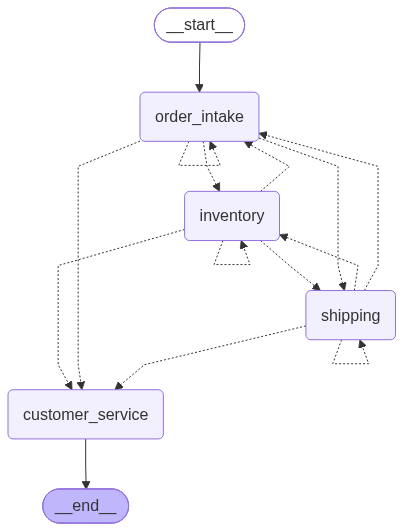

In [13]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

### [4] 실행: 재고가 충분한 경우 / 부족한 경우

같은 그래프에 다른 주문을 흘려보내면, `inventory`가 보내는 메시지의 `content`에 따라 `order_intake`가 다음 수신자를 `shipping` 또는 `customer_service`로 **동적으로** 바꾼다. 그래프 구조는 그대로인데, 실제로 오가는 메시지 경로만 달라지는 것을 로그에서 확인할 수 있다.

In [14]:
def initial_state(product: str, qty: int) -> State:
    return {"order": {"product": product, "qty": qty}, "log": [], "inbox": {}, "next_agent": "", "final": ""}


print("########## 시나리오 1: 재고 충분 (무선 키보드 5개) ##########")
result_ok = app.invoke(initial_state("무선 키보드", 5))

print("\n########## 시나리오 2: 재고 부족 (노이즈캔슬링 헤드셋 5개) ##########")
result_out = app.invoke(initial_state("노이즈캔슬링 헤드셋", 5))

########## 시나리오 1: 재고 충분 (무선 키보드 5개) ##########
  [Message] order_intake -> inventory (request): '무선 키보드' 5개 재고 확인 요청
  [Message] inventory -> order_intake (response): 재고 가능 (보유 10개)
  [Message] order_intake -> shipping (request): '무선 키보드' 5개 배송 준비 요청
  [Message] shipping -> order_intake (response): 운송장번호 TRK-240001 발급, 영업일 기준 2일 내 배송 예정
  [Message] order_intake -> customer_service (notify): 주문이 정상적으로 처리되었습니다. (운송장번호 TRK-240001 발급, 영업일 기준 2일 내 배송 예정)
  [CustomerService -> 고객] 고객님, 주문이 정상적으로 처리되었습니다. 운송장 번호 TRK-240001로 확인하실 수 있으며, 영업일 기준 2일 내에 배송될 예정입니다. 감사합니다!

########## 시나리오 2: 재고 부족 (노이즈캔슬링 헤드셋 5개) ##########
  [Message] order_intake -> inventory (request): '노이즈캔슬링 헤드셋' 5개 재고 확인 요청
  [Message] inventory -> order_intake (response): 재고 부족 (보유 2개, 요청 5개)
  [Message] order_intake -> customer_service (notify): 재고 부족으로 주문을 처리할 수 없습니다. (사유: 재고 부족 (보유 2개, 요청 5개))
  [CustomerService -> 고객] 안녕하세요, 고객님. 요청하신 상품의 재고가 부족하여 주문을 처리할 수 없는 점 양해 부탁드립니다. 다른 상품으로의 교환이나 추가 문의가 필요하시면 언제든지 말씀해 주세요. 감사합니다.

In [15]:
def print_trace(label: str, result: dict):
    print(f"=== {label} ===")
    for m in result["log"]:
        print(f"  {m['sender']:>17} -> {m['receiver']:<17} [{m['type']:>8}] {m['content']}")
    print(f"  최종 안내: {result['final']}\n")


print_trace("시나리오 1 (재고 충분)", result_ok)
print_trace("시나리오 2 (재고 부족)", result_out)

=== 시나리오 1 (재고 충분) ===
       order_intake -> inventory         [ request] '무선 키보드' 5개 재고 확인 요청
          inventory -> order_intake      [response] 재고 가능 (보유 10개)
       order_intake -> shipping          [ request] '무선 키보드' 5개 배송 준비 요청
           shipping -> order_intake      [response] 운송장번호 TRK-240001 발급, 영업일 기준 2일 내 배송 예정
       order_intake -> customer_service  [  notify] 주문이 정상적으로 처리되었습니다. (운송장번호 TRK-240001 발급, 영업일 기준 2일 내 배송 예정)
  최종 안내: 고객님, 주문이 정상적으로 처리되었습니다. 운송장 번호 TRK-240001로 확인하실 수 있으며, 영업일 기준 2일 내에 배송될 예정입니다. 감사합니다!

=== 시나리오 2 (재고 부족) ===
       order_intake -> inventory         [ request] '노이즈캔슬링 헤드셋' 5개 재고 확인 요청
          inventory -> order_intake      [response] 재고 부족 (보유 2개, 요청 5개)
       order_intake -> customer_service  [  notify] 재고 부족으로 주문을 처리할 수 없습니다. (사유: 재고 부족 (보유 2개, 요청 5개))
  최종 안내: 안녕하세요, 고객님. 요청하신 상품의 재고가 부족하여 주문을 처리할 수 없는 점 양해 부탁드립니다. 다른 상품으로의 교환이나 추가 문의가 필요하시면 언제든지 말씀해 주세요. 감사합니다.



### 정리

- 01, 02번 노트북의 **공유 State** 방식과 달리, 이 노트북의 agent들은 서로의 내부 상태를 전혀 모른다. 오직 `Message` 스키마(sender/receiver/type/content)만 공유한다.
- 라우팅은 `next_agent`(직전 메시지의 receiver) 하나로만 결정되므로, 그래프 코드는 "누가 누구에게 응답하는지"에 대한 비즈니스 로직을 전혀 담고 있지 않다. 로직은 전부 agent 노드 내부에 있다.
- `log`에 모든 메시지가 순서대로 남기 때문에, 문제가 생겼을 때 어떤 agent가 어떤 판단으로 어떤 메시지를 보냈는지 그대로 재구성할 수 있다 — 공유 State 방식에서는 이런 대화 이력을 얻으려면 별도로 설계해야 한다.
- 이 예제는 하나의 LangGraph State 안에서 inbox를 시뮬레이션했지만, 실제 분산 시스템에서는 `inbox`가 Kafka 토픽이나 SQS 큐로, 각 agent 노드가 별도의 서비스/프로세스로 대체될 수 있다 — 메시지 스키마와 라우팅 규칙("receiver가 다음 수신자")은 그대로 유지된다.